# Logistic Regression Baseline

This notebook builds a simple, balanced Logistic Regression model to predict startup success.


In [8]:
# Modeling Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed dataset created in 01_exploration.ipynb
df_curr = pd.read_csv(r"C:\Users\mklad\Desktop\Startup_Investment_App\Data\processed\processed_dataset.csv")


## Data preparation

Blank locations are handled before creating the model inputs.


In [9]:
# Fill blank country and region values with an Unknown category
df_curr["country_code"] = (
    df_curr["country_code"]
    .replace(r"^\s*$", np.nan, regex=True)
)

df_curr["region"] = (
    df_curr["region"]
    .replace(r"^\s*$", np.nan, regex=True)
    .fillna("Unknown")
)

df_curr["country_code"] = df_curr["country_code"].fillna("Unknown")

df_curr["country_code"].value_counts().head(20)


country_code
USA        27014
Unknown     5218
GBR         2549
CHN         1382
CAN         1328
IND          877
FRA          872
DEU          744
ISR          661
ESP          477
RUS          360
SWE          340
AUS          328
JPN          316
NLD          313
IRL          303
SGP          264
BRA          255
CHE          236
ITA          234
Name: count, dtype: int64

In [10]:
df_curr["country_code"].isna().sum()

df_curr.head()

,name,Industry,Funding,status,country_code,region,funding_rounds,company_age,success,Funding_log,year_founded,Industry_clean
0,#fame,Media,10000000.0,operating,IND,Mumbai,1,5.0,1,16.118096,2011,Other
1,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,3406878.0,operating,Unknown,Unknown,1,6.0,1,15.041307,2010,Other
2,0-6.com,Curated Web,2000000.0,operating,CHN,Beijing,1,9.0,1,14.508658,2007,Curated Web
3,004 Technologies,Software,0.0,operating,USA,"Springfield, Illinois",1,6.0,1,0.000000,2010,Software
4,01Games Technology,Games,41250.0,operating,HKG,Hong Kong,1,6.0,1,10.627431,2010,Games


In [11]:
# Keep the five most frequent countries and group the remaining countries as Other
top_countries = df_curr["country_code"].value_counts().head(5).index
df_curr["country_code"] = df_curr["country_code"].apply(
    lambda x: x if x in top_countries else "Other"
)


In [12]:
df_curr["country_code"].value_counts()

country_code
USA        27014
Other       9412
Unknown     5218
GBR         2549
CHN         1382
CAN         1328
Name: count, dtype: int64

## Define features and split the data


In [13]:
# Target variable
y = df_curr["success"]

# Feature matrix
X = df_curr[
    [
        "company_age",
        "Funding_log",
        "funding_rounds",
        "Industry_clean",
        "country_code"
    ]
]


In [14]:
from sklearn.model_selection import train_test_split

# Use a stratified 80/20 split so both classes are represented in each set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Raw Data
#   ↓
#Preprocessor
#   ↓
#Scaled + Encoded Data
#   ↓
#Logistic Regression
#   ↓
#Learn Weights

## Preprocessing

Numeric features are scaled and categorical features are one-hot encoded.


In [16]:
#Splitting features into numerical and categorical types for feeding into preprocessor
num_features = ["company_age", "Funding_log", "funding_rounds"]
cat_features = ["Industry_clean", "country_code"]

In [17]:
# A preprocessor scales numeric features and encodes categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

# StandardScaler puts numeric variables on a similar scale.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
#importing our main model and the Pipeline

## Train the Logistic Regression model


In [19]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ]
)

# The pipeline preprocesses X_train, then trains Logistic Regression.
# class_weight="balanced" gives the minority class more importance.


In [20]:
log_reg_pipeline.fit(X_train, y_train)
#Is line me internally ye sab hota hai:

#1 Preprocessor X_train pe fit hota hai
#2 Scaling hoti hai
#3 One-hot encoding hoti hai
#4 Logistic regression weights learn karta hai

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['company_age','Funding_log','funding_rounds','Industry_clean', 'country_code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

## Evaluate the model


In [21]:
from sklearn.metrics import classification_report

y_pred = log_reg_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.61      0.29      1219
           1       0.91      0.61      0.73      8162

    accuracy                           0.61      9381
   macro avg       0.55      0.61      0.51      9381
weighted avg       0.82      0.61      0.68      9381



In [22]:
print("Total rows in the processed dataset:", df_curr.shape[0])


Total rows in the processed dataset: 46903


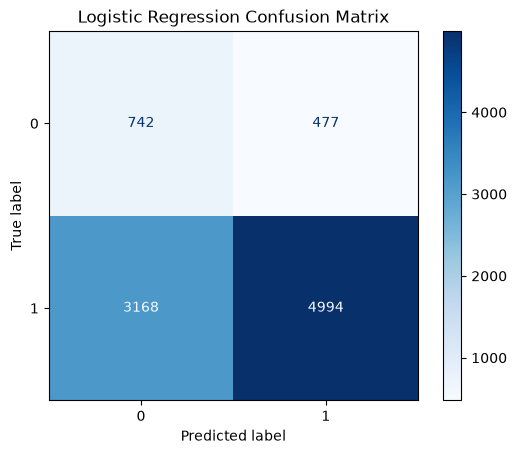

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Inspect prediction errors


In [24]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred

false_positive = results[(results["actual"] == 0) & (results["predicted"] == 1)]
false_positive.head()

,company_age,Funding_log,funding_rounds,Industry_clean,country_code,actual,predicted
36816,3.0,0.000000,2,Hardware + Software,Other,0,1
15628,20.0,15.424949,1,Other,USA,0,1
25500,7.0,15.424949,2,Other,Other,0,1
7713,15.0,15.319588,1,Software,USA,0,1
32616,11.0,14.891290,2,Other,USA,0,1
